# 05 — Baseline Predictive Modeling

## Objective

This notebook establishes baseline machine learning models for predicting customer conversion.

The purpose of baseline modeling is to establish a reference point before developing individual treatment-effect and uplift models.

We will:

- Prepare the modeling dataset
- Separate customer features, treatment, and outcomes
- Split the data into training and testing sets
- Train a Logistic Regression baseline
- Train a Random Forest baseline
- Evaluate classification performance
- Compare model performance
- Examine feature importance
- Analyze probability calibration
- Save baseline model results

The baseline models predict conversion probability.

They do NOT directly estimate individual treatment uplift.

Uplift modeling will be introduced in subsequent notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\raw\criteo-research-uplift-v2.1.csv.gz"
)

print("Dataset exists:", DATA_PATH.exists())

if DATA_PATH.exists():
    print(
        "Dataset size (MB):",
        round(DATA_PATH.stat().st_size / (1024 ** 2), 2)
    )

Dataset exists: True
Dataset size (MB): 297.0


In [3]:
SAMPLE_SIZE = 100_000

df = pd.read_csv(
    DATA_PATH,
    compression="gzip",
    nrows=SAMPLE_SIZE
)

print("Dataset shape:", df.shape)

Dataset shape: (100000, 16)


In [4]:
feature_cols = [f"f{i}" for i in range(12)]

X = df[feature_cols].copy()

y = df["conversion"].copy()

treatment = df["treatment"].copy()

print("Features:", feature_cols)
print("X shape:", X.shape)
print("Target shape:", y.shape)

Features: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']
X shape: (100000, 12)
Target shape: (100000,)


In [5]:
target_distribution = y.value_counts().sort_index()

print(target_distribution)

print("\nConversion rate:", y.mean())

conversion
0    99494
1      506
Name: count, dtype: int64

Conversion rate: 0.00506


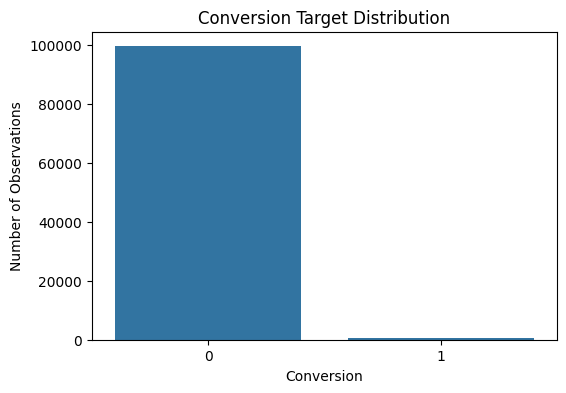

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Conversion Target Distribution")
plt.xlabel("Conversion")
plt.ylabel("Number of Observations")

plt.show()

In [7]:
X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X,
    y,
    treatment,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining conversion rate:", y_train.mean())
print("Testing conversion rate:", y_test.mean())

Training shape: (80000, 12)
Testing shape: (20000, 12)

Training conversion rate: 0.0050625
Testing conversion rate: 0.00505


In [8]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [9]:
logistic_pred = logistic_model.predict(X_test)

logistic_proba = logistic_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [10]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, logistic_pred),
    "Precision": precision_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        logistic_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        logistic_proba
    ),
    "PR_AUC": average_precision_score(
        y_test,
        logistic_proba
    ),
    "Log_Loss": log_loss(
        y_test,
        logistic_proba
    ),
    "Brier_Score": brier_score_loss(
        y_test,
        logistic_proba
    )
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.9354,
 'Precision': 0.06627822286962855,
 'Recall': 0.900990099009901,
 'F1': 0.12347354138398914,
 'ROC_AUC': 0.9718494237483449,
 'PR_AUC': 0.2750845490244005,
 'Log_Loss': 0.21242446582926572,
 'Brier_Score': 0.05318688882663435}

In [11]:
print(
    classification_report(
        y_test,
        logistic_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     19899
           1       0.07      0.90      0.12       101

    accuracy                           0.94     20000
   macro avg       0.53      0.92      0.54     20000
weighted avg       0.99      0.94      0.96     20000



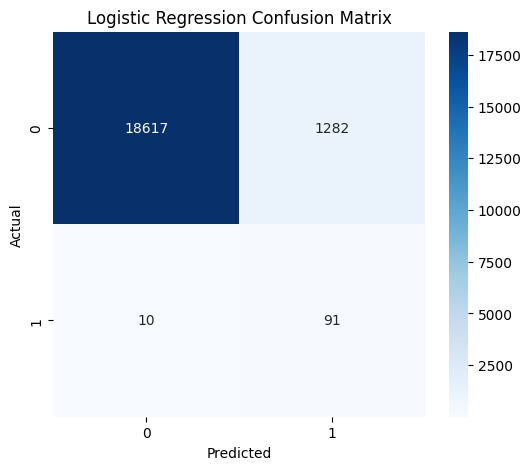

In [12]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [14]:
rf_pred = random_forest_model.predict(X_test)

rf_proba = random_forest_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [15]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_proba
    ),
    "PR_AUC": average_precision_score(
        y_test,
        rf_proba
    ),
    "Log_Loss": log_loss(
        y_test,
        rf_proba
    ),
    "Brier_Score": brier_score_loss(
        y_test,
        rf_proba
    )
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.97335,
 'Precision': 0.13513513513513514,
 'Recall': 0.7920792079207921,
 'F1': 0.23088023088023088,
 'ROC_AUC': 0.9643295175288674,
 'PR_AUC': 0.3690297830157342,
 'Log_Loss': 0.0775577638580178,
 'Brier_Score': 0.02046911804514653}

In [16]:
results_df = pd.DataFrame([
    logistic_results,
    rf_results
])

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
0,Logistic Regression,0.93540,0.066278,0.900990,0.123474,0.971849,0.275085,0.212424,0.053187
1,Random Forest,0.97335,0.135135,0.792079,0.230880,0.964330,0.369030,0.077558,0.020469


In [17]:
results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
0,Logistic Regression,0.93540,0.066278,0.900990,0.123474,0.971849,0.275085,0.212424,0.053187
1,Random Forest,0.97335,0.135135,0.792079,0.230880,0.964330,0.369030,0.077558,0.020469


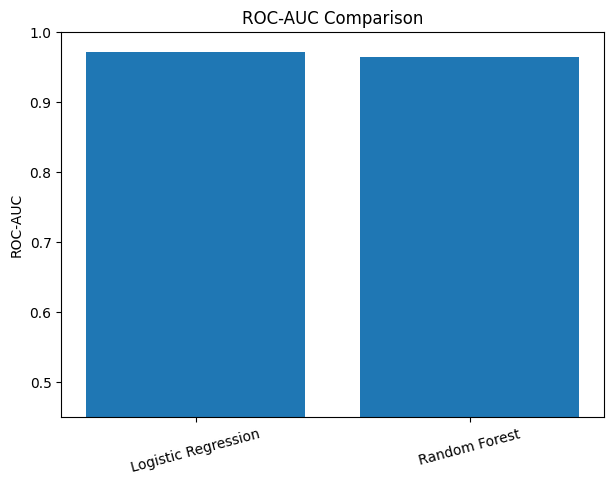

In [18]:
plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["ROC_AUC"]
)

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.ylim(0.45, 1.0)

plt.xticks(rotation=15)
plt.show()

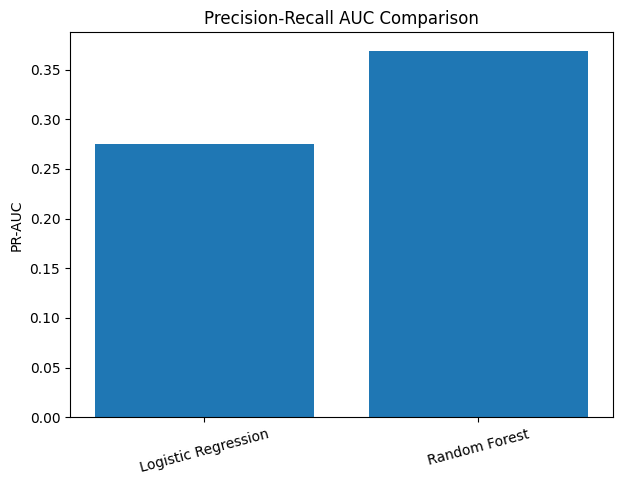

In [19]:
plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["PR_AUC"]
)

plt.title("Precision-Recall AUC Comparison")
plt.ylabel("PR-AUC")

plt.xticks(rotation=15)
plt.show()